# Proyecto 2 · Sistema integrado de clasificación, segmentación y atención
## Notebook 02 — Segmentación de lesiones dermatoscópicas con y sin self-attention

**Curso:** Visión Computacional con Deep Learning — Maestría en Inteligencia Artificial y Ciencia de Datos, UAO

**Integrantes:** Maria Stella Fuentes Diaz · Sergio Luis Castaño Rodríguez · Alejandro Galvez Cardenas · Joan Sebastian Mena Ortega

## Objetivo

Entrenar una U-Net con encoder ResNet-34 preentrenado para segmentar la lesión en
imágenes dermatoscópicas; cuantificar el aporte de un bloque de self-attention en el
cuello de botella de la red, mediante una comparación controlada con y sin el bloque, y
aislar la lesión del fondo de piel a partir de la máscara predicha.

## Problema y datos

Delimitar con precisión el borde de una lesión es un paso previo a su análisis: criterios
clínicos como la asimetría y la irregularidad del borde dependen de saber qué píxeles
pertenecen a la lesión. La segmentación automática es difícil porque el contraste entre
lesión y piel puede ser bajo, los bordes suelen ser difusos, el tamaño relativo de la
lesión varía mucho entre imágenes, y aparecen artefactos como vello, burbujas de
inmersión o el viñeteado circular del dermatoscopio.

Se utiliza **HAM10000** (*Human Against Machine with 10000 training images*; Tschandl
et al., 2018), el conjunto de entrenamiento de la Tarea 3 del challenge ISIC 2018. Reúne
**10.015 imágenes dermatoscópicas** de 600×450 píxeles, correspondientes a **7.470
lesiones** distintas: una misma lesión puede aparecer en varias fotografías. Las imágenes
provienen de dos centros, el Departamento de Dermatología de la Universidad Médica de
Viena (Austria) y una consulta especializada en cáncer de piel en Queensland (Australia).

El diagnóstico de referencia se confirmó por **histopatología en el 53,3%** de las
imágenes; el resto, por seguimiento clínico (37,0%), consenso de expertos (9,0%) o
microscopía confocal (0,7%). En las tres clases malignas o premalignas (`mel`, `bcc`,
`akiec`) la confirmación histopatológica es del 100%. Cada imagen trae además una
**máscara binaria de la lesión**, generada de forma semiautomática y revisada
manualmente, lo que permite resolver clasificación y segmentación sobre las mismas
imágenes.

| Clase | Diagnóstico | Imágenes | % |
| --- | --- | ---: | ---: |
| `nv` | Nevus melanocítico | 6.705 | 66,9 |
| `mel` | Melanoma | 1.113 | 11,1 |
| `bkl` | Lesión benigna tipo queratosis | 1.099 | 11,0 |
| `bcc` | Carcinoma basocelular | 514 | 5,1 |
| `akiec` | Queratosis actínica / carcinoma intraepitelial | 327 | 3,3 |
| `vasc` | Lesión vascular | 142 | 1,4 |
| `df` | Dermatofibroma | 115 | 1,1 |

- **Repositorio:** Harvard Dataverse, DOI [10.7910/DVN/DBW86T](https://doi.org/10.7910/DVN/DBW86T) (licencia CC BY-NC 4.0)
- **Máscaras:** archivo `HAM10000_segmentations_lesion_tschandl.zip` del mismo repositorio

El alcance de este notebook es la **segmentación semántica binaria** (lesión frente a
piel) de una única lesión por imagen. La clasificación y los mecanismos CBAM y Grad-CAM
se desarrollan en el notebook 01.

## Guía del notebook

Ninguna decisión de modelado se toma antes de conocer los datos: la sección 1 caracteriza
imágenes y máscaras; las secciones 2 a 4 definen las métricas, las aumentaciones y la
arquitectura; las secciones 5 a 8 entrenan, evalúan, analizan la atención y aíslan la
lesión. La sección 0 solo prepara el entorno de ejecución.

| Qué buscar | Dónde está |
| --- | --- |
| Partición, ejemplos de máscaras y tamaño relativo de las lesiones | Sección 1 |
| Métricas Dice e IoU y pérdida BCE + Dice | Sección 2 |
| Aumentaciones aplicadas a imagen y máscara | Sección 3 |
| Arquitectura U-Net y bloque de self-attention (fórmula, implementación y verificación) | Sección 4 |
| Entrenamiento con y sin self-attention y curvas de pérdida | Sección 5 |
| Resultados en test, comparación imagen por imagen y prueba de significancia | Sección 6 |
| Mapas de self-attention | Sección 7 |
| Aislamiento de la lesión a partir de la máscara | Sección 8 |
| Checklist de verificación | Sección 9 |

**Antes de ejecutar:** seleccionar *Entorno de ejecución → Cambiar tipo de entorno → GPU
T4*. Duración estimada: entre 1,5 y 2 horas.
Si Colab se desconecta, basta con volver a ejecutar desde arriba: los entrenamientos que
ya terminaron no se repiten, y uno interrumpido continúa desde la última época completada.

## 0. Preparación del entorno

Esta sección deja lista la máquina de Colab: verifica la GPU, conecta Google Drive,
descarga el código y el dataset, y configura las rutas. Se ejecuta una vez por sesión y
es **reanudable**: si Colab se desconecta, basta con volver a ejecutarla desde arriba.

### 0.1 Verificar la GPU

El entrenamiento requiere una GPU. Si la sesión no la tiene, la celda se detiene con
instrucciones para activarla.

In [1]:
import sys
import torch

if not torch.cuda.is_available():
    raise SystemExit(
        'No hay GPU. Entorno de ejecucion -> Cambiar tipo de entorno -> GPU T4, '
        'y vuelve a ejecutar esta celda.'
    )

print('GPU    :', torch.cuda.get_device_name(0))
print('VRAM   :', f'{torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print('torch  :', torch.__version__)
print('CUDA   :', torch.version.cuda)
print('Python :', sys.version.split()[0])

GPU    : Tesla T4
VRAM   : 15.6 GB
torch  : 2.11.0+cu128
CUDA   : 12.8
Python : 3.13.15


### 0.2 Rutas de trabajo

La máquina de Colab se borra al desconectarse, así que se separan dos ubicaciones:

| Qué | Dónde | Por qué |
| --- | --- | --- |
| Dataset (2,6 GB) | `/content/data`, disco de la sesión | El entrenamiento lee cada imagen miles de veces; desde Drive sería mucho más lento |
| Modelos, métricas y figuras | Google Drive | Se guardan desde la primera época, así que una desconexión no borra el trabajo |

In [2]:
from pathlib import Path

RAIZ_DATOS = Path('/content/data')                        # dataset, disco local de la sesion
RAIZ_DRIVE = Path('/content/drive/MyDrive/dermascope')    # modelos, metricas y figuras
REPO_DIR = Path('/content/dermascope')                    # codigo clonado de GitHub

### 0.3 Conectar Google Drive

Se monta Drive y se crean las carpetas donde quedarán los resultados. Colab pedirá
autorización para acceder a la cuenta.

In [3]:
from google.colab import drive

drive.mount('/content/drive')
for sub in ('models', 'reports/results', 'reports/figures'):
    (RAIZ_DRIVE / sub).mkdir(parents=True, exist_ok=True)
print('Drive listo en', RAIZ_DRIVE)

Mounted at /content/drive
Drive listo en /content/drive/MyDrive/dermascope


### 0.4 Descargar el código

Se clona el repositorio público del proyecto; si ya estaba clonado, solo se actualiza
con la última versión. Si la carpeta existe pero está vacía o incompleta (por ejemplo,
por una descarga interrumpida), se descarta y se vuelve a clonar.

In [4]:
REPO_URL = 'https://github.com/mariastella1807/dermascope.git'

import os
import shutil
import subprocess


def clon_valido(ruta):
    """True si la carpeta es un repositorio git con al menos un commit."""
    resultado = subprocess.run(['git', '-C', str(ruta), 'rev-parse', 'HEAD'], capture_output=True)
    return (ruta / '.git').exists() and resultado.returncode == 0


if REPO_DIR.exists() and not clon_valido(REPO_DIR):
    os.chdir('/content')
    shutil.rmtree(REPO_DIR)

if REPO_DIR.exists():
    subprocess.run(['git', '-C', str(REPO_DIR), 'pull', '--ff-only'], check=True)
else:
    subprocess.run(['git', 'clone', REPO_URL, str(REPO_DIR)], check=True)

os.chdir(REPO_DIR)
print('directorio:', Path.cwd())
print(subprocess.run(['git', 'log', '--oneline', '-1'], capture_output=True, text=True).stdout)

directorio: /content/dermascope
84799a9 Agregar el notebook del clasificador ejecutado en Colab



### 0.5 Dependencias

Colab ya incluye las librerías que usa el proyecto (PyTorch, torchvision, scikit-learn,
scipy, pandas y matplotlib). Solo se instalan las de exportación a ONNX, necesarias para
la cuantización. A propósito **no** se instala desde `requirements.txt`: reinstalar
PyTorch sobre el de Colab rompe su compatibilidad con la GPU.

In [5]:
!pip install --quiet onnx onnxruntime onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 88.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 88.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 754.2/754.2 kB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 18.9 MB/s eta 0:00:00


### 0.6 Verificación del entorno

Antes de gastar tiempo de GPU se ejecutan las comprobaciones del proyecto
(`scripts/smoke_test.py`): construyen los modelos, prueban las métricas y verifican que
el proyecto no dependa de librerías innecesarias. No necesitan el dataset. Si alguna falla, el
problema es de versiones y conviene resolverlo aquí.

In [6]:
!python scripts/smoke_test.py

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100% 83.3M/83.3M [00:00<00:00, 153MB/s]
  OK    versiones                  torch 2.11.0+cu128 | torchvision 0.26.0+cu128 | scipy 1.16.3 | pandas 2.2.3 | numpy 2.1.3 | cuda True
  OK    config                     7 clases, semilla 42, herencia de paths.yaml ok
  OK    transforms                 clasificacion 224px, segmentacion 256px, alineacion minima 100.0%
  OK    clasificador + CBAM        sin CBAM 21.29M -> con CBAM 21.33M (+41K params)
  OK    Grad-CAM                   mapa (224, 224), clase 4, rango [0.000, 1.000]
  OK    aislamiento de la lesion   bbox=(92,52,116,96), area=13.3%, satelite descartado
  OK    metricas                   macro_f1=0.932, dice=1.0000, iou=1.0000, pesos ok (rango 0.05-2.68)
  OK    self-attention             softmax(QK^T/sqrt(d))V: filas suman 1, identidad al inicio, estable en float16
  OK    U-Net con y sin self-attent

### 0.7 Descargar el dataset

Se descargan de Harvard Dataverse (DOI `10.7910/DVN/DBW86T`) los metadatos, las
imágenes y las máscaras. La descarga es anónima y toma unos minutos; los archivos que ya
existen se saltan.

In [7]:
%%bash
set -e
RAW=/content/data/raw
mkdir -p $RAW

dl() {  # dl <id> <destino>
  if [ -s "$2" ]; then echo "ya existe: $(basename $2)"; return; fi
  curl -sS -L --retry 5 --retry-delay 3 -C - \
    -o "$2" "https://dataverse.harvard.edu/api/access/datafile/$1"
  echo "$(basename $2): $(du -h $2 | cut -f1)"
}

dl 4338392 $RAW/HAM10000_metadata.tab
dl 3838943 $RAW/segmentations.zip
dl 3172585 $RAW/HAM10000_images_part_1.zip
dl 3172584 $RAW/HAM10000_images_part_2.zip

ls -lh $RAW

HAM10000_metadata.tab: 812K
segmentations.zip: 11M
HAM10000_images_part_1.zip: 1.3G
HAM10000_images_part_2.zip: 1.4G
total 2.6G
-rw-r--r-- 1 root root 1.3G Sep 18 11:13 HAM10000_images_part_1.zip
-rw-r--r-- 1 root root 1.4G Sep 18 11:14 HAM10000_images_part_2.zip
-rw-r--r-- 1 root root 811K Sep 18 11:13 HAM10000_metadata.tab
-rw-r--r-- 1 root root  11M Sep 18 11:13 segmentations.zip


### 0.8 Descomprimir

Se extraen las imágenes y las máscaras. La extracción es reanudable: salta los archivos
que ya están completos.

In [8]:
!python scripts/extract_data.py /content/data/raw/HAM10000_images \
    /content/data/raw/HAM10000_images_part_1.zip \
    /content/data/raw/HAM10000_images_part_2.zip

!python scripts/extract_data.py /content/data/raw/HAM10000_segmentations \
    /content/data/raw/segmentations.zip

HAM10000_images_part_1.zip: 5000 entradas -> /content/data/raw/HAM10000_images
  500/5000  extraidos=500 omitidos=0
  1000/5000  extraidos=1000 omitidos=0
  1500/5000  extraidos=1500 omitidos=0
  2000/5000  extraidos=2000 omitidos=0
  2500/5000  extraidos=2500 omitidos=0
  3000/5000  extraidos=3000 omitidos=0
  3500/5000  extraidos=3500 omitidos=0
  4000/5000  extraidos=4000 omitidos=0
  4500/5000  extraidos=4500 omitidos=0
  5000/5000  extraidos=5000 omitidos=0
HAM10000_images_part_2.zip: 5015 entradas -> /content/data/raw/HAM10000_images
  500/5015  extraidos=500 omitidos=0
  1000/5015  extraidos=1000 omitidos=0
  1500/5015  extraidos=1500 omitidos=0
  2000/5015  extraidos=2000 omitidos=0
  2500/5015  extraidos=2500 omitidos=0
  3000/5015  extraidos=3000 omitidos=0
  3500/5015  extraidos=3500 omitidos=0
  4000/5015  extraidos=4000 omitidos=0
  4500/5015  extraidos=4500 omitidos=0
  5000/5015  extraidos=5000 omitidos=0
  5015/5015  extraidos=5015 omitidos=0

Total: {'extraidos': 10015

### 0.9 Configuración de rutas

El código lee las rutas de `configs/paths.yaml`. Este archivo local las ajusta a Colab
sin modificar el repositorio (los `configs/*.local.yaml` no se versionan).

In [9]:
Path('configs/paths.local.yaml').write_text(
    'paths:\n'
    f'  ham_metadata: {RAIZ_DATOS.as_posix()}/raw/HAM10000_metadata.tab\n'
    f'  ham_images: {RAIZ_DATOS.as_posix()}/raw/HAM10000_images\n'
    f'  seg_masks: {RAIZ_DATOS.as_posix()}/raw/HAM10000_segmentations\n'
    f'  processed: {RAIZ_DATOS.as_posix()}/processed\n'
    f'  models: {(RAIZ_DRIVE / "models").as_posix()}\n'
    f'  reports: {(RAIZ_DRIVE / "reports").as_posix()}\n',
    encoding='utf-8',
)
print(Path('configs/paths.local.yaml').read_text(encoding='utf-8'))

paths:
  ham_metadata: /content/data/raw/HAM10000_metadata.tab
  ham_images: /content/data/raw/HAM10000_images
  seg_masks: /content/data/raw/HAM10000_segmentations
  processed: /content/data/processed
  models: /content/drive/MyDrive/dermascope/models
  reports: /content/drive/MyDrive/dermascope/reports



### 0.10 Utilidades del notebook

Importaciones comunes, las carpetas de resultados en Drive, el dispositivo de cómputo y
dos funciones auxiliares: una guarda cada figura para el informe y otra lee los
resultados que escriben los scripts de entrenamiento.

In [10]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from src.config import load_config, resolve

DIR_MODELOS = RAIZ_DRIVE / 'models'
DIR_RESULTADOS = RAIZ_DRIVE / 'reports' / 'results'
DIR_FIGURAS = RAIZ_DRIVE / 'reports' / 'figures'
DISPOSITIVO = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def guardar_figura(fig, nombre):
    """Guarda la figura en Drive para usarla en el informe."""
    ruta = DIR_FIGURAS / f'{nombre}.png'
    fig.savefig(ruta, dpi=150, bbox_inches='tight')
    print('figura guardada en', ruta)


def leer_json(nombre):
    return json.loads((DIR_RESULTADOS / nombre).read_text(encoding='utf-8'))


print('dispositivo:', DISPOSITIVO)

dispositivo: cuda


## 1. Imágenes y máscaras

Antes de modelar se construye la partición, se observan ejemplos de imagen y máscara y se
mide qué fracción de cada imagen ocupa la lesión.

### 1.1 Partición

Se construye con la misma semilla y el mismo agrupamiento por `lesion_id` que en el
notebook 01, así que la partición es idéntica: una lesión que está en test para el
clasificador también lo está para el segmentador.

In [11]:
!python -m src.data.build_splits --config configs/paths.yaml

=== Imagenes por split y clase ===
split  test  train   val    All
dx                             
akiec    51    225    51    327
bcc      65    375    74    514
bkl     166    771   162   1099
df       19     77    19    115
mel     160    798   155   1113
nv     1020   4667  1018   6705
vasc     21    101    20    142
All    1502   7014  1499  10015

=== Lesiones unicas por split ===
split
test     1120
train    5230
val      1120

=== Cobertura de mascaras ===
Imagenes con mascara: 10015 de 10015
split  test  train   val    All
dx                             
akiec    51    225    51    327
bcc      65    375    74    514
bkl     166    771   162   1099
df       19     77    19    115
mel     160    798   155   1113
nv     1020   4667  1018   6705
vasc     21    101    20    142
All    1502   7014  1499  10015

=== Ejemplos por clase en test (confiabilidad del F1) ===
df        19  <-- muy pocos, F1 con varianza alta
vasc      21  <-- muy pocos, F1 con varianza alta
akiec     51
bc

Verificación de la partición: cobertura de máscaras, imágenes por split y comprobación
de que ninguna lesión quedó repartida entre dos splits.

In [12]:
cfg_seg = load_config('configs/segmentation.yaml')
splits = pd.read_csv(resolve(cfg_seg.paths.processed) / 'splits.csv')

fuga = int((splits.groupby('lesion_id')['split'].nunique() > 1).sum())
assert fuga == 0, f'{fuga} lesiones aparecen en mas de un split'
print(f"imagenes con mascara: {splits['has_mask'].sum()} de {len(splits)}")
print(splits['split'].value_counts().loc[['train', 'val', 'test']])
print('\nverificado: ninguna lesion aparece en mas de un split')

imagenes con mascara: 10015 de 10015
split
train    7014
val      1499
test     1502
Name: count, dtype: int64

verificado: ninguna lesion aparece en mas de un split


### 1.2 Ejemplos de imagen y máscara

Cuatro imágenes de entrenamiento con su máscara. Las máscaras se generaron de forma
semiautomática y se revisaron manualmente; no son una anotación experta píxel a píxel,
lo que acota el Dice máximo alcanzable y debe considerarse al interpretar los resultados.

figura guardada en /content/drive/MyDrive/dermascope/reports/figures/ejemplos_mascaras.png


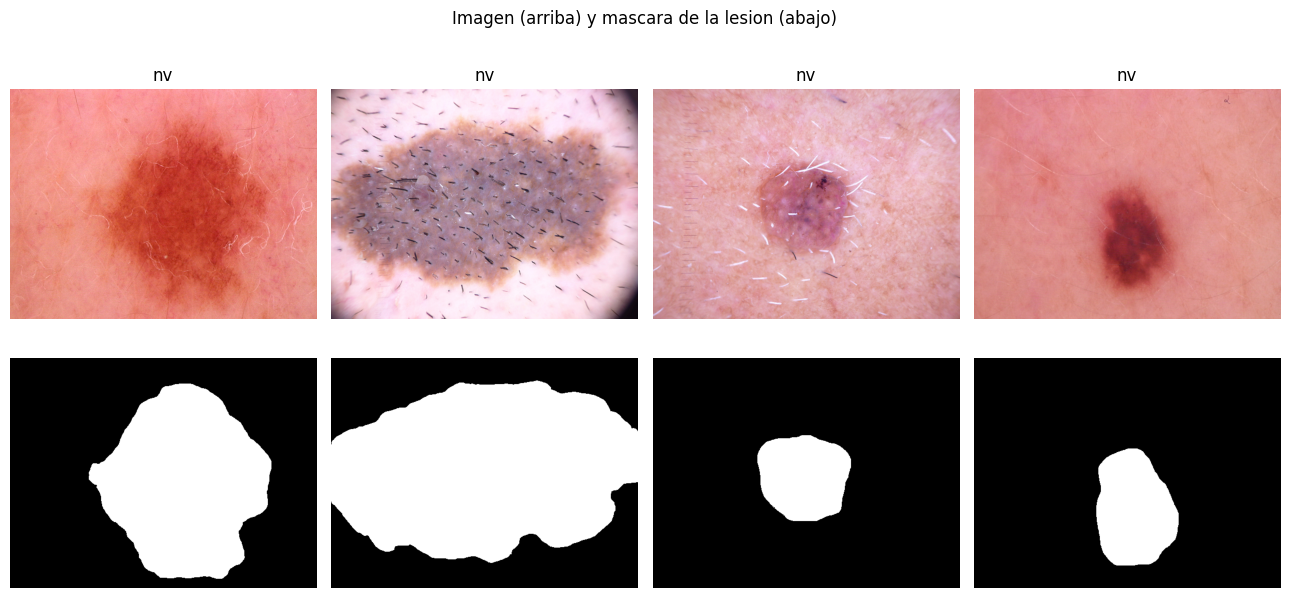

In [13]:
from PIL import Image

from src.data.datasets import read_mask, read_rgb

ejemplos = splits[splits['split'] == 'train'].sample(4, random_state=7)
fig, axes = plt.subplots(2, 4, figsize=(13, 6.5))
for j, (_, fila) in enumerate(ejemplos.iterrows()):
    axes[0, j].imshow(read_rgb(fila['image_path']))
    axes[0, j].set_title(fila['dx'])
    axes[1, j].imshow(read_mask(fila['mask_path']), cmap='gray')
for ax in axes.ravel():
    ax.axis('off')
plt.suptitle('Imagen (arriba) y mascara de la lesion (abajo)')
plt.tight_layout()
guardar_figura(fig, 'ejemplos_mascaras')
plt.show()

### 1.3 Tamaño relativo de las lesiones

Esta medida sustenta dos decisiones: trabajar a 256 píxeles (reducir la resolución
borraría lesiones diminutas, pero no las de tamaño típico) y usar el término Dice en la
pérdida (si el fondo domina el área, la entropía cruzada sola favorece predecir "todo
fondo"). Se calcula sobre una muestra de 1.000 máscaras.

fraccion de la imagen ocupada por la lesion (1000 mascaras):
  mediana 21.9%  |  p10 6.0%  |  p90 52.0%
  a 256 px, una lesion del percentil 10 mide unos 63 x 63 pixeles
figura guardada en /content/drive/MyDrive/dermascope/reports/figures/tamano_lesiones.png


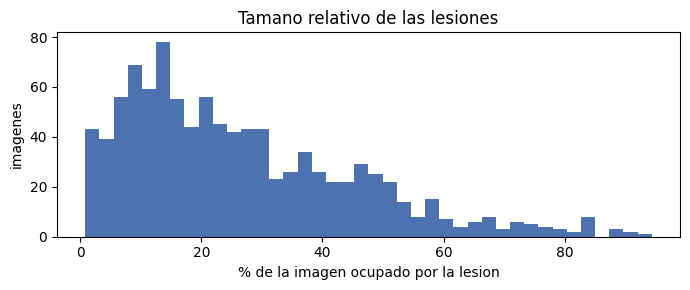

In [14]:
muestra = splits.sample(1000, random_state=0)
fraccion_lesion = np.array([read_mask(ruta).mean() for ruta in muestra['mask_path']])

print(f'fraccion de la imagen ocupada por la lesion ({len(muestra)} mascaras):')
print(f'  mediana {np.median(fraccion_lesion):.1%}  |  p10 {np.percentile(fraccion_lesion, 10):.1%}  |  p90 {np.percentile(fraccion_lesion, 90):.1%}')
pixeles_lado_256 = np.sqrt(np.percentile(fraccion_lesion, 10)) * 256
print(f'  a 256 px, una lesion del percentil 10 mide unos {pixeles_lado_256:.0f} x {pixeles_lado_256:.0f} pixeles')

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(100 * fraccion_lesion, bins=40, color='#4C72B0')
ax.set_xlabel('% de la imagen ocupado por la lesion')
ax.set_ylabel('imagenes')
ax.set_title('Tamano relativo de las lesiones')
plt.tight_layout()
guardar_figura(fig, 'tamano_lesiones')
plt.show()

## 2. Métricas: Dice e IoU

Ambas miden el solapamiento entre la máscara predicha $P$ y la de referencia $G$, entre
0 (sin solapamiento) y 1 (idénticas):

$$\text{Dice} = \frac{2\,|P \cap G|}{|P| + |G|} \qquad\qquad \text{IoU} = \frac{|P \cap G|}{|P \cup G|}$$

Dice cuenta dos veces la intersección, por lo que es más indulgente con estructuras
pequeñas; las dos están relacionadas exactamente por $\text{Dice} = \dfrac{2\,\text{IoU}}{1 + \text{IoU}}$.
Se calculan por imagen y se promedian, para que las lesiones grandes no dominen el
resultado.

### 2.1 Cálculo a mano y verificación cruzada

Se calculan Dice e IoU a mano sobre dos máscaras de 4×4 y se comparan con la
implementación del proyecto (`src/eval/metrics.py`).

In [15]:
from src.eval.metrics import bce_dice_loss, dice_coefficient, iou_score

real = np.array([[0, 1, 1, 0],
                 [0, 1, 1, 0],
                 [0, 1, 1, 0],
                 [0, 0, 0, 0]])
prediccion = np.array([[0, 0, 1, 1],
                       [0, 1, 1, 1],
                       [0, 1, 1, 0],
                       [0, 0, 0, 0]])

interseccion = int((real & prediccion).sum())      # 5
union = int((real | prediccion).sum())             # 8
dice_mano = 2 * interseccion / (real.sum() + prediccion.sum())
iou_mano = interseccion / union
print(f'a mano:  |P∩G| = {interseccion}  |P∪G| = {union}  Dice = {dice_mano:.4f}  IoU = {iou_mano:.4f}')

# La implementacion del proyecto recibe logits: +10 donde hay lesion, -10 donde no
logits = torch.tensor(np.where(prediccion == 1, 10.0, -10.0), dtype=torch.float32)[None, None]
objetivo = torch.tensor(real, dtype=torch.float32)[None, None]
dice_proyecto = dice_coefficient(logits, objetivo).item()
iou_proyecto = iou_score(logits, objetivo).item()
print(f'proyecto:                        Dice = {dice_proyecto:.4f}  IoU = {iou_proyecto:.4f}')

coincide_metricas = np.isclose(dice_mano, dice_proyecto, atol=1e-5) and np.isclose(iou_mano, iou_proyecto, atol=1e-5)
assert coincide_metricas
assert np.isclose(dice_mano, 2 * iou_mano / (1 + iou_mano))
print('verificado: coinciden con src.eval.metrics y cumplen Dice = 2 IoU / (1 + IoU)')

a mano:  |P∩G| = 5  |P∪G| = 8  Dice = 0.7692  IoU = 0.6250
proyecto:                        Dice = 0.7692  IoU = 0.6250
verificado: coinciden con src.eval.metrics y cumplen Dice = 2 IoU / (1 + IoU)


### 2.2 La pérdida: BCE + Dice

La entropía cruzada binaria (BCE) se calcula píxel a píxel. Si la lesión ocupa una
fracción pequeña de la imagen, un modelo que prediga "todo fondo" acierta la mayoría de
los píxeles y su BCE ya es baja. El término Dice *suave*, calculado con probabilidades
para que sea derivable (Milletari et al., 2016), optimiza directamente el solapamiento:

$$\mathcal{L} = (1-\lambda)\,\text{BCE} + \lambda\,\big(1 - \text{Dice}_{\text{suave}}\big) \qquad \lambda = 0{,}5$$

La celda separa los dos términos para una predicción "todo fondo" y para una predicción
perfecta. En "todo fondo" la BCE queda lejos de ser alta, porque la mayoría de los píxeles
son fondo y están bien clasificados; el término Dice, en cambio, queda cerca de 1, su peor
valor posible, porque no hay ningún solapamiento con la lesión.

In [16]:
objetivo = torch.zeros(1, 1, 64, 64)
objetivo[:, :, 25:39, 25:39] = 1.0                         # lesion del ~5% de la imagen

todo_fondo = torch.full_like(objetivo, -6.0)               # predice "sin lesion" en todas partes
perfecta = torch.where(objetivo > 0.5, 6.0, -6.0)


def terminos_perdida(logits, objetivo):
    bce = torch.nn.functional.binary_cross_entropy_with_logits(logits, objetivo).item()
    probabilidades = torch.sigmoid(logits)
    dice_suave = (2 * (probabilidades * objetivo).sum() + 1) / (probabilidades.sum() + objetivo.sum() + 1)
    return bce, 1 - dice_suave.item(), bce_dice_loss(logits, objetivo).item()


print(f"{'prediccion':12s} {'BCE':>7s} {'1 - Dice':>9s} {'BCE+Dice':>9s}")
for nombre, logits in [('todo fondo', todo_fondo), ('perfecta', perfecta)]:
    bce, termino_dice, total = terminos_perdida(logits, objetivo)
    print(f'{nombre:12s} {bce:7.3f} {termino_dice:9.3f} {total:9.3f}')

bce_fondo, dice_fondo, _ = terminos_perdida(todo_fondo, objetivo)
assert bce_fondo < 0.5 and dice_fondo > 0.95
print('\nverificado: ante "todo fondo" la BCE es baja, pero el termino Dice esta cerca de su peor valor (1)')

prediccion       BCE  1 - Dice  BCE+Dice
todo fondo     0.290     0.990     0.640
perfecta       0.002     0.025     0.014

verificado: ante "todo fondo" la BCE es baja, pero el termino Dice esta cerca de su peor valor (1)


## 3. Aumentaciones de imagen y máscara

Las transformaciones geométricas (rotación, escala, desplazamiento y volteos) deben
aplicarse **idénticas** a la imagen y a su máscara; de lo contrario el modelo aprendería
bordes equivocados. `torchvision.transforms.v2` lo garantiza cuando la máscara se
envuelve en `tv_tensors.Mask`. Las transformaciones de color solo afectan a la imagen.
Los volteos y rotaciones preservan la etiqueta, porque una imagen dermatoscópica no
tiene orientación canónica.

Se muestran cuatro sorteos sobre la misma imagen: la máscara, superpuesta en verde, debe
seguir a la lesión en todos.

figura guardada en /content/drive/MyDrive/dermascope/reports/figures/aumentaciones_segmentacion.png


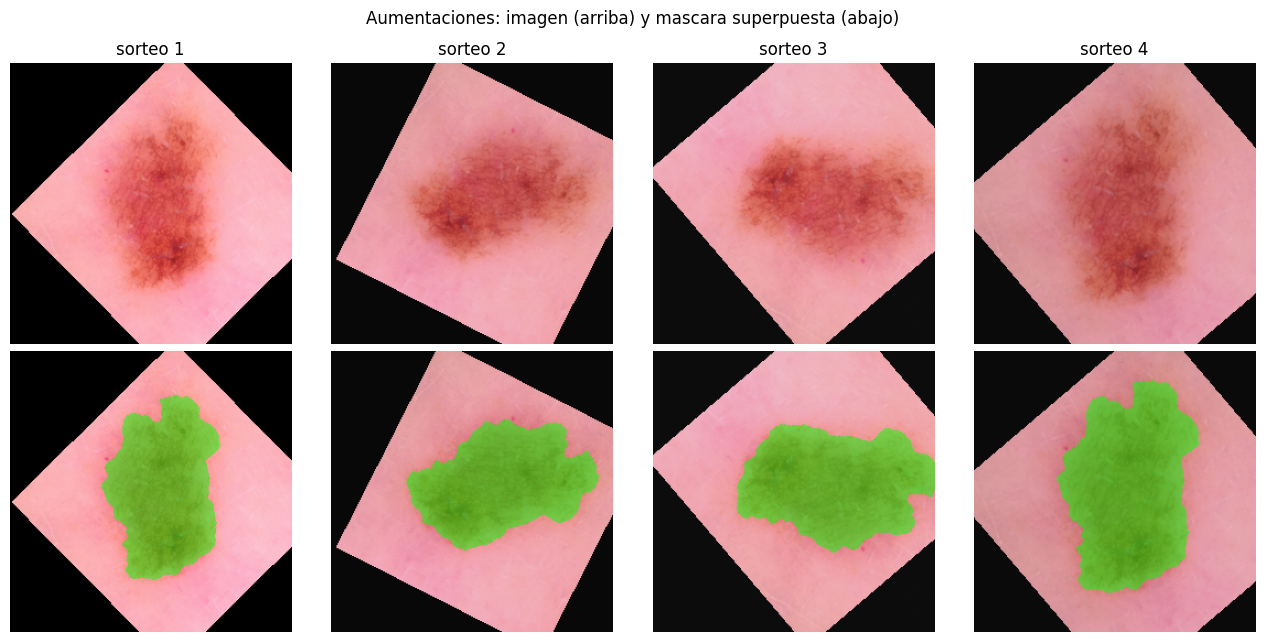

In [17]:
from src.data import transforms as T
from src.data.datasets import make_dataloaders
from src.data.transforms import IMAGENET_MEAN, IMAGENET_STD

_, datasets_seg = make_dataloaders(cfg_seg, 'segmentation')
media = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
desviacion = torch.tensor(IMAGENET_STD).view(3, 1, 1)


def desnormalizar(imagen):
    return (imagen * desviacion + media).clamp(0, 1).permute(1, 2, 0).numpy()


torch.manual_seed(3)
fig, axes = plt.subplots(2, 4, figsize=(13, 6.5))
for j in range(4):
    imagen, mascara = datasets_seg['train'][5]
    rgb = desnormalizar(imagen)
    superpuesta = rgb.copy()
    lesion = mascara[0].numpy() > 0.5
    superpuesta[lesion] = 0.5 * superpuesta[lesion] + 0.5 * np.array([0.0, 1.0, 0.0])
    axes[0, j].imshow(rgb)
    axes[1, j].imshow(superpuesta)
    axes[0, j].set_title(f'sorteo {j + 1}')
for ax in axes.ravel():
    ax.axis('off')
plt.suptitle('Aumentaciones: imagen (arriba) y mascara superpuesta (abajo)')
plt.tight_layout()
guardar_figura(fig, 'aumentaciones_segmentacion')
plt.show()

## 4. El modelo: U-Net + self-attention

```
Imagen 256 ─ stem /2 ─ layer1 /4 ─ layer2 /8 ─ layer3 /16 ─ layer4 /32 (8x8)
               │          │           │           │                │
               │          │           │           │         self-attention
               │          │           │           │                │
Máscara 256 ─ dec0 ─── dec1 ────── dec2 ────── dec3 ────── dec4 ───┘
                    (skip connections: concatenan el mapa del encoder de la misma escala)
```

- **Encoder:** ResNet-34 preentrenada en ImageNet, la misma familia que el clasificador.
  Cada etapa reduce la resolución a la mitad y aumenta el número de canales.
- **Decoder:** arquitectura U-Net (Ronneberger et al., 2015). Cada bloque duplica la
  resolución, **concatena** el mapa del encoder de la misma escala y aplica dos
  convoluciones 3×3. Estas *skip connections* recuperan el detalle espacial que el
  encoder perdió al reducir, y son las que permiten un borde preciso.
- **Cuello de botella:** el bloque de self-attention (secciones 4.2 y 4.3).

### 4.1 Recorrido de las formas

Se predice la forma de la salida de cada bloque a partir de la arquitectura y se
verifica con un forward real, recorriendo la red bloque por bloque.

In [18]:
from src.models.segmenter import build_segmenter

unet = build_segmenter(cfg_seg, override_attention=True).eval()
x = torch.randn(1, 3, 256, 256)

formas_esperadas = {
    'stem   (/2)': (1, 64, 128, 128), 'layer1 (/4)': (1, 64, 64, 64), 'layer2 (/8)': (1, 128, 32, 32),
    'layer3 (/16)': (1, 256, 16, 16), 'layer4 (/32)': (1, 512, 8, 8), 'atencion': (1, 512, 8, 8),
    'dec4   (/16)': (1, 256, 16, 16), 'dec3   (/8)': (1, 128, 32, 32), 'dec2   (/4)': (1, 64, 64, 64),
    'dec1   (/2)': (1, 64, 128, 128), 'dec0   (/1)': (1, 32, 256, 256), 'head   (logits)': (1, 1, 256, 256),
}

with torch.no_grad():
    x0 = unet.stem(x)
    x1 = unet.layer1(unet.pool(x0))
    x2 = unet.layer2(x1)
    x3 = unet.layer3(x2)
    x4 = unet.layer4(x3)
    xa = unet.attention(x4)
    d4 = unet.dec4(xa, x3)
    d3 = unet.dec3(d4, x2)
    d2 = unet.dec2(d3, x1)
    d1 = unet.dec1(d2, x0)
    d0 = unet.dec0(d1)
    salida = unet.head(d0)

formas_reales = dict(zip(formas_esperadas, [tuple(t.shape) for t in (x0, x1, x2, x3, x4, xa, d4, d3, d2, d1, d0, salida)]))
for nombre, forma in formas_reales.items():
    print(f'{nombre:16s} {str(forma):20s} {"ok" if forma == formas_esperadas[nombre] else "DISTINTA"}')
formas_ok = formas_reales == formas_esperadas
assert formas_ok
assert torch.allclose(salida, unet(x), atol=1e-5)
print('\nverificado: las formas coinciden y el recorrido manual da lo mismo que unet(x)')

stem   (/2)      (1, 64, 128, 128)    ok
layer1 (/4)      (1, 64, 64, 64)      ok
layer2 (/8)      (1, 128, 32, 32)     ok
layer3 (/16)     (1, 256, 16, 16)     ok
layer4 (/32)     (1, 512, 8, 8)       ok
atencion         (1, 512, 8, 8)       ok
dec4   (/16)     (1, 256, 16, 16)     ok
dec3   (/8)      (1, 128, 32, 32)     ok
dec2   (/4)      (1, 64, 64, 64)      ok
dec1   (/2)      (1, 64, 128, 128)    ok
dec0   (/1)      (1, 32, 256, 256)    ok
head   (logits)  (1, 1, 256, 256)     ok

verificado: las formas coinciden y el recorrido manual da lo mismo que unet(x)


### 4.2 El bloque de self-attention

Es la operación central del Transformer (Vaswani et al., 2017) y del Vision Transformer
(Dosovitskiy et al., 2021):

$$\text{Atencion}(Q,K,V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

ViT divide la imagen en parches; aquí **cada posición del mapa de 8×8 que entrega
`layer4` es un token**, así que hay 64 tokens de dimensión 512. Paso a paso:

1. Aplanar el mapa `(B, 512, 8, 8)` en una secuencia `(B, 64, 512)`.
2. Sumar **embeddings de posición** aprendibles: la atención es invariante a
   permutaciones y, sin ellos, no sabría dónde está cada token.
3. Normalizar (`LayerNorm`) y proyectar a $Q$, $K$ y $V$ con tres capas lineales.
4. Calcular la matriz de atención `(B, 64, 64)`: cada fila indica cuánto atiende ese
   token a cada uno de los demás, y suma 1.
5. Combinar los $V$ con esos pesos, proyectar y **sumar a la entrada** (conexión
   residual).

A diferencia de una convolución 3×3, que solo relaciona cada posición con sus vecinas,
la auto-atención relaciona cada posición con **todas** en una sola capa: cada zona del
borde puede "consultar" dónde está el resto de la lesión. La proyección de salida se
inicializa en ceros, de modo que al comenzar el entrenamiento el bloque devuelve su
entrada sin alterar los pesos preentrenados.

La celda implementa estos pasos y los compara con `src/models/attention.py`.

In [19]:
import math


def auto_atencion_didactica(bloque, mapa):
    '''Self-attention paso a paso, usando las capas de un bloque SelfAttention2d.'''
    B, C, H, W = mapa.shape
    tokens = mapa.flatten(2).transpose(1, 2)                    # 1. (B, N, C), N = H*W
    t = tokens + bloque.pos_embed                               # 2. posicion
    t = bloque.norm(t)                                          # 3. LayerNorm
    Q, K, V = bloque.query(t), bloque.key(t), bloque.value(t)   #    proyecciones (B, N, C)
    puntajes = Q @ K.transpose(1, 2) / math.sqrt(C)             # 4. (B, N, N)
    pesos = torch.softmax(puntajes, dim=-1)                     #    cada fila suma 1
    combinacion = pesos @ V                                     # 5. (B, N, C)
    tokens = tokens + bloque.proj(combinacion)                  #    residual
    return tokens.transpose(1, 2).reshape(B, C, H, W), pesos


from src.models.attention import SelfAttention2d

torch.manual_seed(0)
bloque = SelfAttention2d(channels=512, n_tokens=64)
torch.nn.init.normal_(bloque.proj.weight, std=0.02)            # proyeccion no nula para que la prueba sea exigente

mapa = torch.randn(2, 512, 8, 8)
with torch.no_grad():
    salida_didactica, pesos_didacticos = auto_atencion_didactica(bloque, mapa)
    salida_proyecto = bloque(mapa)

coincide_atencion = torch.allclose(salida_didactica, salida_proyecto, atol=1e-5)
print('matriz de atencion:', tuple(pesos_didacticos.shape), '| filas suman 1:',
      torch.allclose(pesos_didacticos.sum(dim=-1), torch.ones(2, 64)))
print('auto_atencion_didactica coincide con src.models.attention.SelfAttention2d:', coincide_atencion)
assert coincide_atencion

matriz de atencion: (2, 64, 64) | filas suman 1: True
auto_atencion_didactica coincide con src.models.attention.SelfAttention2d: True


### 4.3 Estabilidad numérica con precisión mixta

El entrenamiento usa precisión mixta: la mayoría de las operaciones se hacen en `float16`,
que ocupa la mitad de memoria y es más rápido en la GPU, pero cuyo máximo representable
es **65.504**. El producto $QK^T$ suma 512 productos por cada par de tokens y, a medida que
los pesos crecen durante el entrenamiento, puede superar ese límite. El resultado se vuelve
infinito, el softmax devuelve `NaN` y el modelo deja de aprender. Una primera corrida con
self-attention se detuvo así en la época 8: la pérdida pasó a `NaN` y el Dice de validación
a 0.

Por eso el bloque calcula $QK^T$, el softmax y la combinación con $V$ en `float32`, aunque
el resto de la red siga en `float16`. La celda reproduce el desbordamiento con dos vectores
de 512 componentes y comprueba que el bloque del proyecto se mantiene finito con pesos
grandes.

In [20]:
q_grande = torch.full((1, 512), 12.0)
k_grande = torch.full((512, 1), 12.0)
print(f'Q K^T en float32: {(q_grande @ k_grande).item():,.0f}')
print(f'Q K^T en float16: {(q_grande.half() @ k_grande.half()).item()}   (maximo de float16: {torch.finfo(torch.float16).max:,.0f})')

# Bloque en float16 con pesos de Q y K grandes, como los que aparecen tras varias epocas
torch.manual_seed(0)
bloque_grande = SelfAttention2d(channels=512, n_tokens=64).half()
x_grande = torch.randn(2, 512, 8, 8).half()
with torch.no_grad():
    bloque_grande.query.weight.normal_(std=3.0)
    bloque_grande.key.weight.normal_(std=3.0)
    bloque_grande.proj.weight.normal_(std=0.02)
    t = bloque_grande.norm(x_grande.flatten(2).transpose(1, 2) + bloque_grande.pos_embed)
    puntajes_fp16 = bloque_grande.query(t) @ bloque_grande.key(t).transpose(1, 2)
    salida_grande = bloque_grande(x_grande)
print(f'Q K^T calculado en float16: {int(torch.isinf(puntajes_fp16).sum()):,} de {puntajes_fp16.numel():,} entradas son infinitas')
atencion_estable = bool(torch.isfinite(salida_grande).all())
print('salida del bloque en float16 con pesos grandes, sin NaN ni infinitos:', atencion_estable)
assert atencion_estable

Q K^T en float32: 73,728
Q K^T en float16: inf   (maximo de float16: 65,504)
Q K^T calculado en float16: 4,352 de 8,192 entradas son infinitas
salida del bloque en float16 con pesos grandes, sin NaN ni infinitos: True


### 4.4 Costo cuadrático de la auto-atención

El costo de la auto-atención crece con el **cuadrado** del número de tokens, porque cada
token se compara con todos los demás. Por eso el bloque se ubica en el cuello de botella,
donde el mapa es más pequeño. La tabla compara el tamaño de la matriz de atención en cada
etapa del encoder.

In [21]:
filas = []
for etapa, lado in [('layer4 (/32)', 8), ('layer3 (/16)', 16), ('layer2 (/8)', 32), ('layer1 (/4)', 64)]:
    n_tokens = lado * lado
    filas.append({'etapa': etapa, 'mapa': f'{lado}x{lado}', 'tokens': n_tokens,
                  'entradas de la matriz de atencion': n_tokens ** 2})
display(pd.DataFrame(filas).set_index('etapa'))
print('En layer1 la matriz tendria 16 millones de entradas por imagen: 1.024 veces mas que en layer4.')

,mapa,tokens,entradas de la matriz de atencion
etapa,,,
layer4 (/32),8x8,64,4096
layer3 (/16),16x16,256,65536
layer2 (/8),32x32,1024,1048576
layer1 (/4),64x64,4096,16777216


En layer1 la matriz tendria 16 millones de entradas por imagen: 1.024 veces mas que en layer4.


### 4.5 Parámetros con y sin el bloque

Se cuantifica cuántos parámetros añade el bloque y cómo se reparten los dos grupos de
tasa de aprendizaje: el encoder preentrenado con la tasa base, y la atención y el decoder,
que parten de cero, con una tasa 10 veces mayor.

In [22]:
unet_sin = build_segmenter(cfg_seg, override_attention=False)
n_con = sum(p.numel() for p in unet.parameters())
n_sin = sum(p.numel() for p in unet_sin.parameters())
print(f'U-Net sin self-attention: {n_sin:,} parametros')
print(f'U-Net con self-attention: {n_con:,} parametros  (+{n_con - n_sin:,}, un {100 * (n_con - n_sin) / n_sin:.1f}% mas)')

grupos = unet.param_groups(cfg_seg.train.lr, cfg_seg.train.head_lr_multiplier)
for nombre, grupo in zip(['encoder preentrenado', 'atencion + decoder (nuevos)'], grupos):
    print(f"{nombre:28s} lr = {grupo['lr']:.0e}   parametros = {sum(p.numel() for p in grupo['params']):,}")
del unet, unet_sin

U-Net sin self-attention: 24,521,697 parametros
U-Net con self-attention: 25,606,113 parametros  (+1,084,416, un 4.4% mas)
encoder preentrenado         lr = 1e-04   parametros = 21,284,672
atencion + decoder (nuevos)  lr = 1e-03   parametros = 4,321,441


## 5. Entrenamiento

El script `src/train/train_segmenter.py` sigue el mismo esquema que el clasificador:
`AdamW` con tasas de aprendizaje diferenciadas, `ReduceLROnPlateau(factor=0.5,
patience=2)` sobre la pérdida de validación, precisión mixta, checkpoint por **Dice de
validación** y estado de reanudación guardado al terminar cada época. No hay parada
temprana: las dos corridas completan las 25 épocas, de modo que la comparación no depende de
cuándo se detuvo cada una; el checkpoint conserva la mejor época. Si la pérdida de validación
deja de ser un número finito, el script se detiene de inmediato en lugar de seguir gastando
épocas.

### 5.1 Verificación rápida del ciclo

Antes del entrenamiento completo, el ciclo `zero_grad → forward → pérdida → backward →
step`, escrito aquí paso a paso, debe reducir la pérdida sobre un lote fijo de 8
imágenes.

In [23]:
from torch.utils.data import DataLoader, Subset

lote_fijo = DataLoader(Subset(datasets_seg['val'], range(8)), batch_size=4, shuffle=False)

torch.manual_seed(0)
modelo = build_segmenter(cfg_seg).to(DISPOSITIVO)
optimizador = torch.optim.AdamW(
    modelo.param_groups(cfg_seg.train.lr, cfg_seg.train.head_lr_multiplier),
    weight_decay=cfg_seg.train.weight_decay,
)

historial_prueba = []
modelo.train()
for paso in range(10):
    perdida_total = 0.0
    for imagenes, mascaras in lote_fijo:
        imagenes, mascaras = imagenes.to(DISPOSITIVO), mascaras.to(DISPOSITIVO)
        optimizador.zero_grad()                                          # 1
        logits = modelo(imagenes)                                        # 2
        perdida = bce_dice_loss(logits, mascaras, cfg_seg.train.dice_weight)   # 3
        perdida.backward()                                               # 4
        optimizador.step()                                               # 5
        perdida_total += perdida.item()
    historial_prueba.append(perdida_total / len(lote_fijo))

print('perdida por paso:', [round(p, 3) for p in historial_prueba])
assert historial_prueba[-1] < historial_prueba[0]
print('verificado: el ciclo reduce la perdida sobre un lote fijo')
del modelo, optimizador

perdida por paso: [0.698, 0.565, 0.562, 0.511, 0.485, 0.474, 0.463, 0.454, 0.446, 0.437]
verificado: el ciclo reduce la perdida sobre un lote fijo


### 5.2 Entrenar con self-attention (unos 40 a 50 minutos)

Al terminar se evalúa el **mejor** checkpoint sobre test y se guardan en Drive el modelo,
las métricas y el Dice e IoU de cada imagen de test. Si la sesión se interrumpió a mitad
del entrenamiento, al volver a ejecutarla continúa desde la última época completada.

La función `entrenamiento_completo` decide si hay que entrenar: un resultado se reutiliza
solo si tiene todas las épocas y ninguna pérdida `NaN`. En otro caso se conserva una copia
con el sufijo `_incompleto` y se vuelve a entrenar.

In [24]:
import shutil


def entrenamiento_completo(nombre_json):
    ruta = DIR_RESULTADOS / nombre_json
    if not ruta.exists():
        return False
    historial = leer_json(nombre_json)['history']
    finito = all(np.isfinite(h['train_loss']) and np.isfinite(h['val_loss']) for h in historial)
    if len(historial) >= cfg_seg.train.epochs and finito:
        print(f'Ya entrenado ({len(historial)} epocas): se usa el resultado guardado en Drive.')
        return True
    copia = ruta.with_name(ruta.stem + '_incompleto.json')
    if not copia.exists():
        shutil.copy(ruta, copia)
    motivo = 'tiene perdidas NaN' if not finito else f'tiene {len(historial)} de {cfg_seg.train.epochs} epocas'
    print(f'{nombre_json} {motivo}: se vuelve a entrenar (copia del resultado anterior en {copia.name}).')
    return False


if not entrenamiento_completo('segmentation_attn.json'):
    !python -m src.train.train_segmenter --config configs/segmentation.yaml

Ya entrenado (25 epocas): se usa el resultado guardado en Drive.


### 5.3 Entrenar sin self-attention: comparación controlada (unos 40 a 50 minutos)

Para atribuir la diferencia al bloque, la segunda corrida solo puede diferir en él: misma
semilla, partición, pérdida y número de épocas; las capas comunes arrancan con los mismos
pesos iniciales y los lotes llegan en el mismo orden.

In [25]:
if not entrenamiento_completo('segmentation_noattn.json'):
    !python -m src.train.train_segmenter --config configs/segmentation.yaml --no-attention

Ya entrenado (25 epocas): se usa el resultado guardado en Drive.


### 5.4 Curvas de entrenamiento

Pérdida de entrenamiento frente a validación, para detectar sobreajuste, y Dice de
validación por época para las dos corridas.

figura guardada en /content/drive/MyDrive/dermascope/reports/figures/curvas_segmentador.png


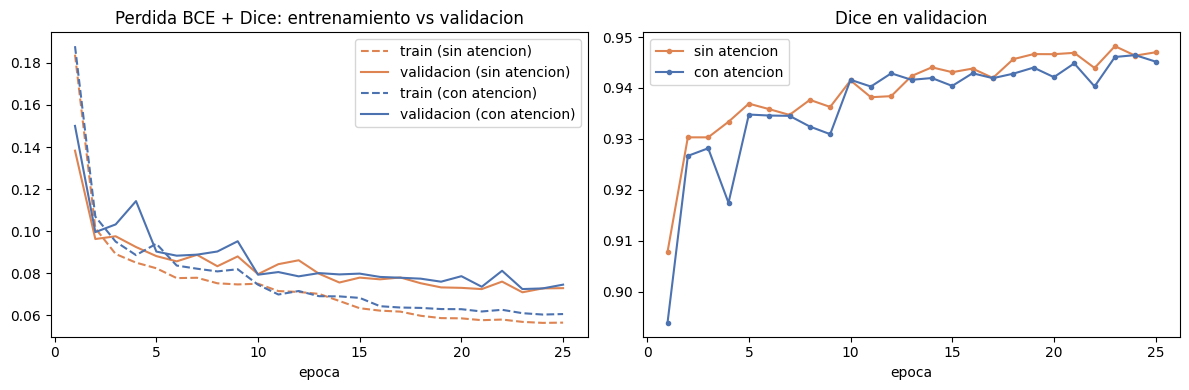

sin atencion: 25 epocas en 60 min, mejor Dice de validacion 0.9482 en la epoca 23
con atencion: 25 epocas en 61 min, mejor Dice de validacion 0.9464 en la epoca 24


In [26]:
res_con = leer_json('segmentation_attn.json')
res_sin = leer_json('segmentation_noattn.json')
COLORES = {'sin atencion': '#DD8452', 'con atencion': '#4C72B0'}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for res, nombre in [(res_sin, 'sin atencion'), (res_con, 'con atencion')]:
    h = pd.DataFrame(res['history'])
    axes[0].plot(h['epoch'], h['train_loss'], '--', color=COLORES[nombre], label=f'train ({nombre})')
    axes[0].plot(h['epoch'], h['val_loss'], '-', color=COLORES[nombre], label=f'validacion ({nombre})')
    axes[1].plot(h['epoch'], h['val_dice'], '-o', markersize=3, color=COLORES[nombre], label=nombre)
axes[0].set_title('Perdida BCE + Dice: entrenamiento vs validacion')
axes[1].set_title('Dice en validacion')
for ax in axes:
    ax.set_xlabel('epoca')
    ax.legend()
plt.tight_layout()
guardar_figura(fig, 'curvas_segmentador')
plt.show()

for res, nombre in [(res_sin, 'sin atencion'), (res_con, 'con atencion')]:
    h = pd.DataFrame(res['history'])
    mejor = h.loc[h['val_dice'].idxmax()]
    print(f"{nombre}: {len(h)} epocas en {res['train_minutes']:.0f} min, "
          f"mejor Dice de validacion {mejor['val_dice']:.4f} en la epoca {int(mejor['epoch'])}")

## 6. Resultados en test

Se consolidan las métricas de test de las dos corridas en una tabla comparativa.

In [27]:
!python -m src.eval.compare_ablation --cls-config configs/classification.yaml --skip-localization


=== ablacion_cbam ===
              modelo  params_M  tamano_MB  accuracy  balanced_acc  macro_F1  F1_akiec  F1_bcc  F1_bkl  F1_df  F1_mel  F1_nv  F1_vasc
ResNet-34 (sin CBAM)     21.29      85.30    0.7250        0.7262    0.6376    0.5093  0.7391  0.5867 0.5957  0.4233 0.8362   0.7727
    ResNet-34 + CBAM     21.33      85.47    0.7197        0.7459    0.6496    0.5691  0.7044  0.6383 0.5660  0.4545 0.8241   0.7907

=== comparacion_segmentacion ===
                              modelo  params_M   Dice    IoU  min_entrenamiento
U-Net ResNet-34 (sin self-attention)     24.52 0.9479 0.9082               59.6
    U-Net ResNet-34 + self-attention     25.61 0.9454 0.9053               61.1

Tablas escritas en /content/drive/MyDrive/dermascope/reports/results


Tabla comparativa con y sin self-attention: parámetros, Dice, IoU y minutos de
entrenamiento.

In [28]:
tabla_seg = pd.read_csv(DIR_RESULTADOS / 'comparacion_segmentacion.csv').set_index('modelo')
display(tabla_seg)

,params_M,Dice,IoU,min_entrenamiento
modelo,,,,
U-Net ResNet-34 (sin self-attention),24.52,0.9479,0.9082,59.6
U-Net ResNet-34 + self-attention,25.61,0.9454,0.9053,61.1


### 6.1 Dice imagen por imagen

Un promedio puede ocultar dónde ayuda la atención. Cada punto del gráfico es una imagen
de test: los puntos por encima de la diagonal son imágenes que el modelo con atención
segmentó mejor.

Dice medio en test: con atencion 0.9454 | sin atencion 0.9479
imagenes donde la atencion mejora el Dice en mas de 0,05: 29
imagenes donde lo empeora en mas de 0,05:              46
figura guardada en /content/drive/MyDrive/dermascope/reports/figures/dice_por_imagen.png


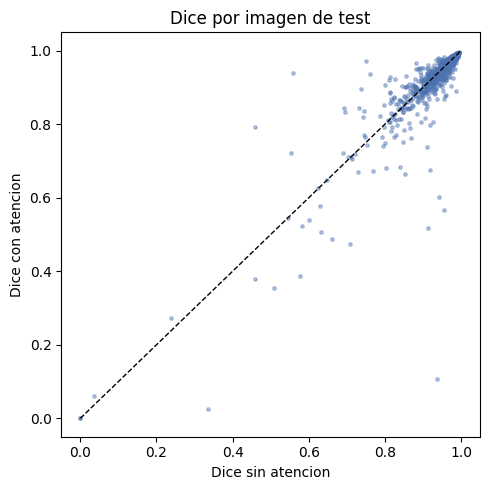

In [29]:
def cargar_segmentador(con_atencion):
    etiqueta = 'attn' if con_atencion else 'noattn'
    modelo = build_segmenter(cfg_seg, override_attention=con_atencion)
    estado = torch.load(DIR_MODELOS / f'segmenter_{etiqueta}_best.pt', map_location=DISPOSITIVO)
    modelo.load_state_dict(estado['model'])
    return modelo.to(DISPOSITIVO).eval()


segmentador_con = cargar_segmentador(True)
segmentador_sin = cargar_segmentador(False)

cargador_test = DataLoader(datasets_seg['test'], batch_size=16, shuffle=False, num_workers=cfg_seg.data.num_workers)
dice_por_imagen = {'con atencion': [], 'sin atencion': []}
with torch.no_grad():
    for imagenes, mascaras in cargador_test:
        imagenes, mascaras = imagenes.to(DISPOSITIVO), mascaras.to(DISPOSITIVO)
        for modelo, nombre in [(segmentador_con, 'con atencion'), (segmentador_sin, 'sin atencion')]:
            dice_por_imagen[nombre] += dice_coefficient(modelo(imagenes), mascaras).cpu().tolist()
dice_con = np.array(dice_por_imagen['con atencion'])
dice_sin = np.array(dice_por_imagen['sin atencion'])

print(f'Dice medio en test: con atencion {dice_con.mean():.4f} | sin atencion {dice_sin.mean():.4f}')
print(f'imagenes donde la atencion mejora el Dice en mas de 0,05: {(dice_con - dice_sin > 0.05).sum()}')
print(f'imagenes donde lo empeora en mas de 0,05:              {(dice_sin - dice_con > 0.05).sum()}')

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(dice_sin, dice_con, s=6, alpha=0.4, color='#4C72B0')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_xlabel('Dice sin atencion')
ax.set_ylabel('Dice con atencion')
ax.set_title('Dice por imagen de test')
plt.tight_layout()
guardar_figura(fig, 'dice_por_imagen')
plt.show()

### 6.2 ¿La diferencia supera al azar del conjunto de test?

La diferencia de Dice medio entre los dos modelos es pequeña, así que conviene estimar si
podría deberse a qué imágenes quedaron en test. Se usa un **bootstrap pareado** (Efron y
Tibshirani, 1993) sobre el Dice de cada imagen:

1. Se sortean 1.502 imágenes del test con reemplazo.
2. Sobre **las mismas** imágenes se promedia la diferencia de Dice entre los dos modelos.
3. Se repite 10.000 veces.

El intervalo entre los percentiles 2,5 y 97,5 es un intervalo de confianza del 95%: si
contiene el 0, los datos no permiten afirmar que un modelo segmente mejor que el otro. La
prueba no mide la variación entre entrenamientos con distintas semillas.

In [30]:
diferencia_dice = dice_con - dice_sin
generador = np.random.default_rng(42)
medias_bootstrap = np.array([
    diferencia_dice[generador.integers(0, len(diferencia_dice), len(diferencia_dice))].mean()
    for _ in range(10_000)
])
bajo, alto = np.percentile(medias_bootstrap, [2.5, 97.5])
tabla_bootstrap_seg = pd.DataFrame([{
    'Dice con atencion': dice_con.mean(), 'Dice sin atencion': dice_sin.mean(),
    'diferencia': diferencia_dice.mean(), 'IC95 inferior': bajo, 'IC95 superior': alto,
    '% sorteos en que gana la atencion': 100 * (medias_bootstrap > 0).mean(),
}], index=['Dice medio'])
tabla_bootstrap_seg.to_csv(DIR_RESULTADOS / 'comparacion_segmentacion_bootstrap.csv')
display(tabla_bootstrap_seg.round(4))
print(f'imagenes en que la atencion da mayor Dice: {(diferencia_dice > 0).sum()} de {len(diferencia_dice)}')

,Dice con atencion,Dice sin atencion,diferencia,IC95 inferior,IC95 superior,% sorteos en que gana la atencion
Dice medio,0.9454,0.9479,-0.0024,-0.0046,-0.0005,0.69


imagenes en que la atencion da mayor Dice: 788 de 1502


### 6.3 Predicciones sobre imágenes de test

Se muestran las cuatro imágenes donde los dos modelos más difieren, que son las más
informativas para analizar el efecto del bloque.

figura guardada en /content/drive/MyDrive/dermascope/reports/figures/predicciones_segmentacion.png


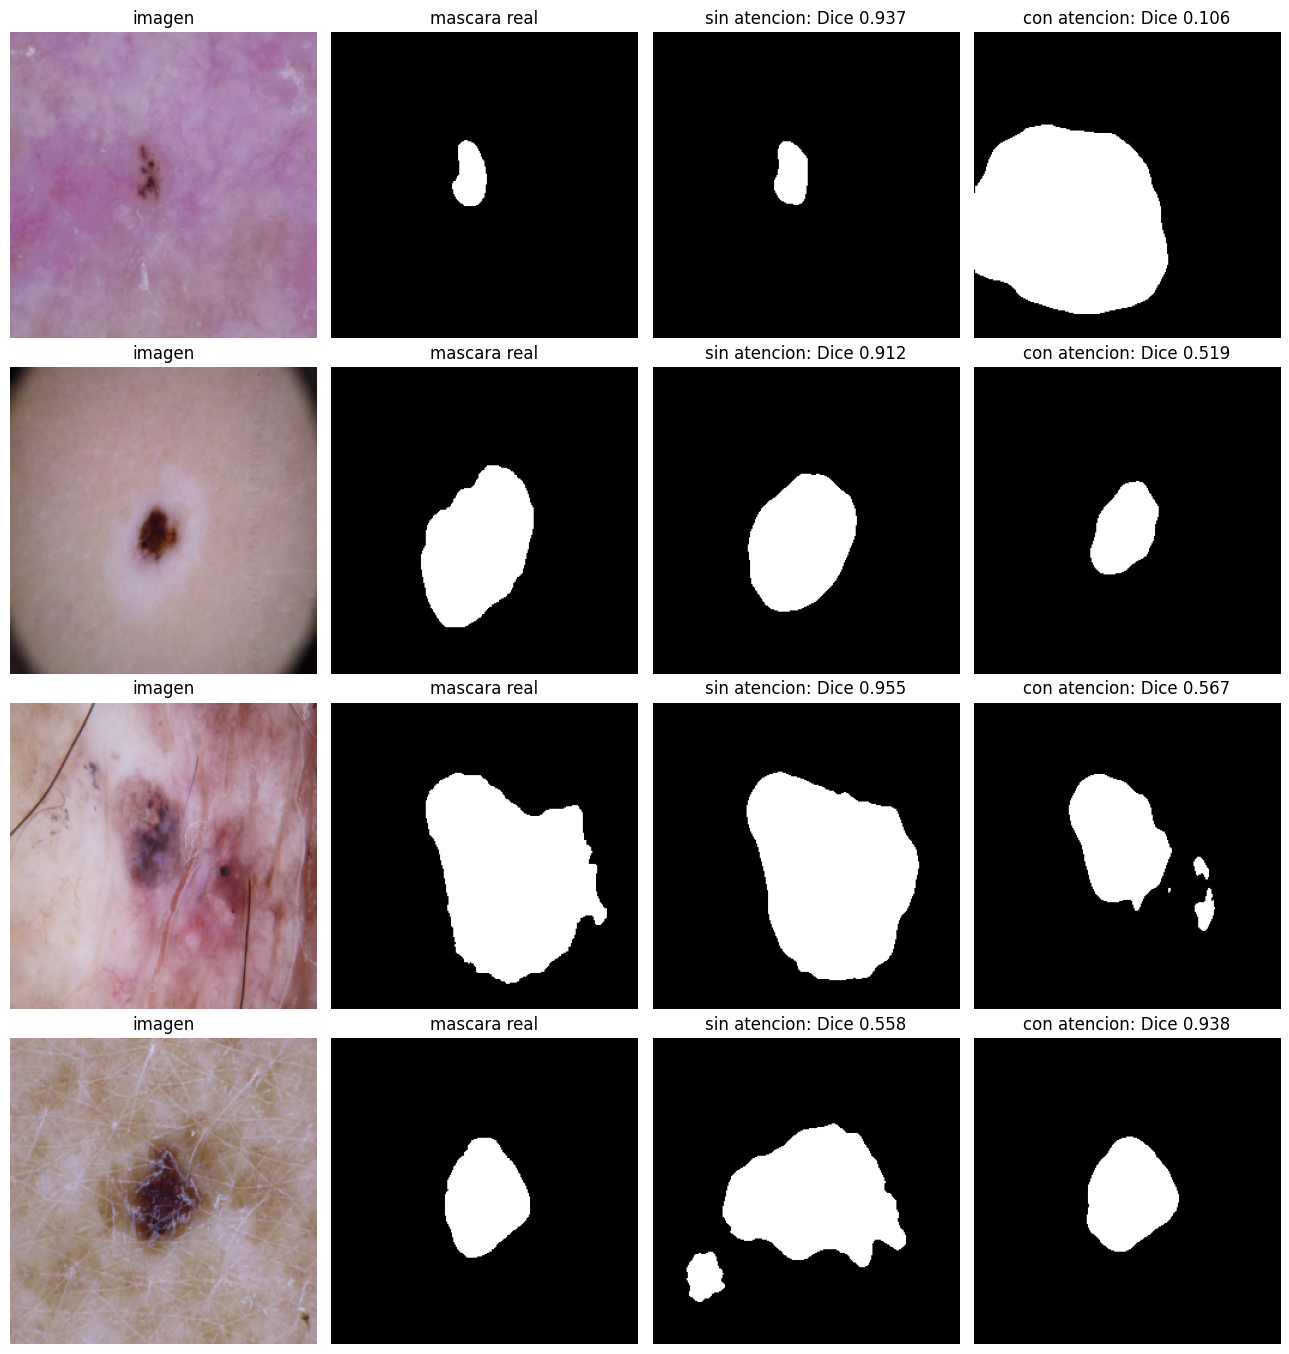

In [31]:
diferencias = np.abs(dice_con - dice_sin)
indices = np.argsort(diferencias)[::-1][:4]

fig, axes = plt.subplots(len(indices), 4, figsize=(13, 3.4 * len(indices)), squeeze=False)
with torch.no_grad():
    for i, idx in enumerate(indices):
        imagen, mascara = datasets_seg['test'][int(idx)]
        x = imagen.unsqueeze(0).to(DISPOSITIVO)
        axes[i, 0].imshow(desnormalizar(imagen))
        axes[i, 0].set_title('imagen')
        axes[i, 1].imshow(mascara[0], cmap='gray')
        axes[i, 1].set_title('mascara real')
        for j, (modelo, nombre, dice) in enumerate(
            [(segmentador_sin, 'sin atencion', dice_sin[idx]), (segmentador_con, 'con atencion', dice_con[idx])], start=2
        ):
            probabilidad = torch.sigmoid(modelo(x))[0, 0].cpu()
            axes[i, j].imshow(probabilidad > 0.5, cmap='gray')
            axes[i, j].set_title(f'{nombre}: Dice {dice:.3f}')
for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
guardar_figura(fig, 'predicciones_segmentacion')
plt.show()

## 7. Mapas de self-attention

El bloque conserva su última matriz de atención, de tamaño 64×64. Se elige un token, es
decir, una celda de la grilla de 8×8, y se dibuja su fila: cuánto atiende ese token a
cada una de las 64 posiciones. Se compara la celda con más lesión frente a la celda con
menos lesión; el recuadro blanco marca el token elegido.

Se usa una imagen de test bien segmentada cuya lesión ocupa entre el 15% y el 35% de la
imagen, alrededor de la mediana de la sección 1.3: así la grilla tiene celdas de lesión y
celdas de piel. La misma imagen se usa en la sección 8.

imagen de test 1253: la lesion ocupa 29.8%, Dice con atencion 0.995
figura guardada en /content/drive/MyDrive/dermascope/reports/figures/mapa_self_attention.png


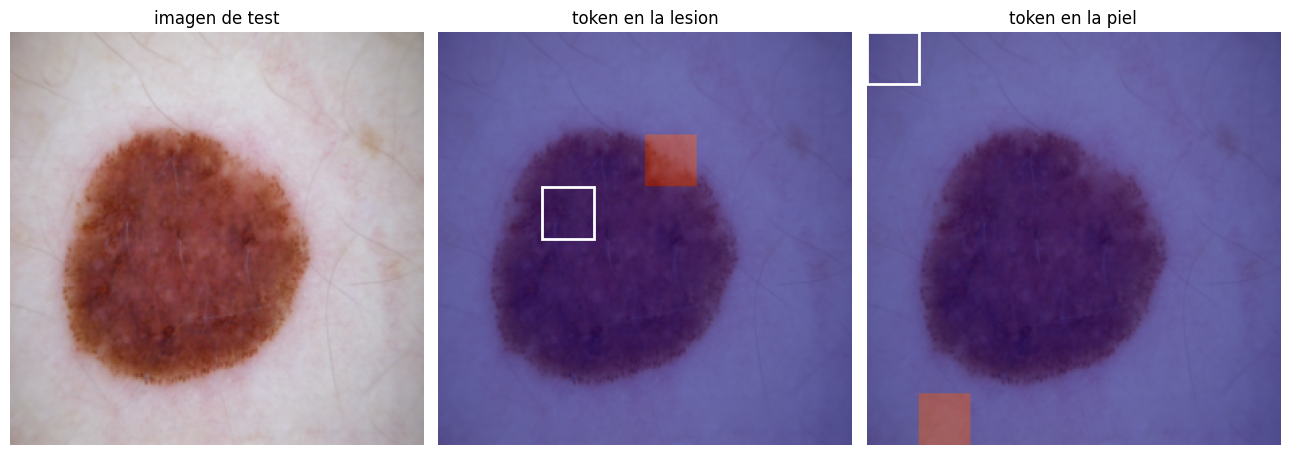

In [32]:
from matplotlib.patches import Rectangle

# Imagen bien segmentada con una lesion de tamano intermedio (el test no se baraja: mismo orden que dice_con)
rutas_mascaras = datasets_seg['test'].frame['mask_path'][:len(dice_con)]
fraccion_test = np.array([read_mask(ruta).mean() for ruta in rutas_mascaras])
candidatas = np.where((fraccion_test > 0.15) & (fraccion_test < 0.35))[0]
if len(candidatas) == 0:                                   # sin lesiones de ese tamano: se usan todas
    candidatas = np.arange(len(dice_con))
idx = int(candidatas[np.argmax(dice_con[candidatas])])
print(f'imagen de test {idx}: la lesion ocupa {fraccion_test[idx]:.1%}, Dice con atencion {dice_con[idx]:.3f}')
imagen, mascara = datasets_seg['test'][idx]
with torch.no_grad():
    segmentador_con(imagen.unsqueeze(0).to(DISPOSITIVO))
atencion = segmentador_con.attention.last_attention[0].cpu()        # (64, 64)

# Fraccion de lesion en cada celda de la grilla 8x8 (cada celda cubre 32x32 pixeles)
fraccion_celdas = torch.nn.functional.avg_pool2d(mascara[None], kernel_size=32)[0, 0]
celda_lesion = divmod(int(fraccion_celdas.argmax()), 8)       # la celda con mas lesion
celda_fondo = divmod(int(fraccion_celdas.argmin()), 8)        # la celda con menos lesion

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
axes[0].imshow(desnormalizar(imagen))
axes[0].set_title('imagen de test')
for ax, (fila, columna), nombre in [(axes[1], celda_lesion, 'token en la lesion'), (axes[2], celda_fondo, 'token en la piel')]:
    pesos = atencion[fila * 8 + columna].view(1, 1, 8, 8)
    pesos = torch.nn.functional.interpolate(pesos, size=(256, 256), mode='nearest')[0, 0]
    ax.imshow(desnormalizar(imagen))
    ax.imshow(pesos, cmap='jet', alpha=0.5)
    ax.add_patch(Rectangle((columna * 32, fila * 32), 32, 32, fill=False, edgecolor='white', linewidth=2))
    ax.set_title(nombre)
for ax in axes:
    ax.axis('off')
plt.tight_layout()
guardar_figura(fig, 'mapa_self_attention')
plt.show()

## 8. Aislamiento de la lesión

A partir de la máscara predicha se extrae la lesión del fondo de piel. Antes de recortar,
la máscara se limpia en tres pasos (`src/explain/isolate.py`):

1. **Cierre morfológico:** rellena huecos pequeños, habituales cuando un pelo cruza la
   lesión. La **dilatación** es un *max pooling* con paso 1; la **erosión** es el mínimo
   de cada ventana, que equivale a `-max_pool(-máscara)`. Cerrar es dilatar y luego
   erosionar.
2. **Región conectada más grande:** hay una sola lesión por imagen, así que cualquier
   región suelta se descarta como ruido.
3. **Caja del recorte:** fila y columna mínima y máxima de la máscara, con un pequeño
   margen de contexto alrededor de la lesión.

### 8.1 Verificación del cierre con max pooling

Sobre una máscara de 9×9 con un hueco de un píxel, el cierre debe rellenar el hueco sin
agrandar la región.

In [33]:
import torch.nn.functional as F

mascara_con_hueco = torch.zeros(1, 1, 9, 9)
mascara_con_hueco[:, :, 2:7, 2:7] = 1.0
mascara_con_hueco[:, :, 4, 4] = 0.0                      # hueco de un pixel en el centro

dilatada = F.max_pool2d(mascara_con_hueco, kernel_size=3, stride=1, padding=1)
cerrada = -F.max_pool2d(-dilatada, kernel_size=3, stride=1, padding=1)

print('antes:\n', mascara_con_hueco[0, 0].int().numpy())
print('despues del cierre:\n', cerrada[0, 0].int().numpy())
cierre_ok = cerrada[0, 0, 4, 4].item() == 1.0 and torch.equal(cerrada[:, :, 2:7, 2:7], torch.ones(1, 1, 5, 5))
assert cierre_ok
print('verificado: el cierre relleno el hueco sin agrandar la region')

antes:
 [[0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 1 1 1 1 1 0 0]
 [0 0 1 1 1 1 1 0 0]
 [0 0 1 1 0 1 1 0 0]
 [0 0 1 1 1 1 1 0 0]
 [0 0 1 1 1 1 1 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]]
despues del cierre:
 [[0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 1 1 1 1 1 0 0]
 [0 0 1 1 1 1 1 0 0]
 [0 0 1 1 1 1 1 0 0]
 [0 0 1 1 1 1 1 0 0]
 [0 0 1 1 1 1 1 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]]
verificado: el cierre relleno el hueco sin agrandar la region


### 8.2 Del modelo al recorte

Sobre la imagen de test de la sección 7, a su resolución original: se predice la
máscara, se limpia y se muestran el borde predicho, la lesión sin fondo y el recorte a la
caja de la lesión.

figura guardada en /content/drive/MyDrive/dermascope/reports/figures/aislamiento_lesion.png


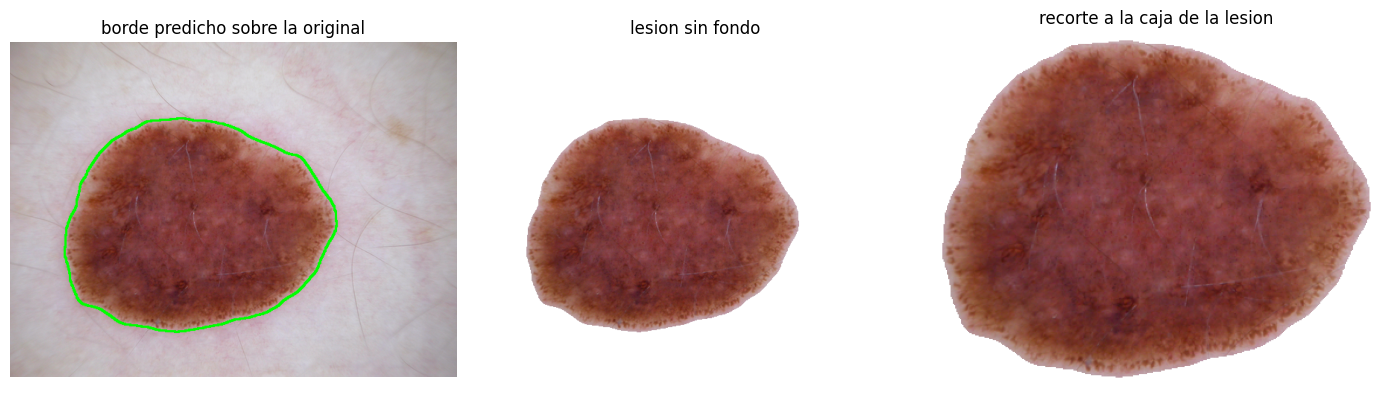

imagen 600x450 | caja x=65 y=94 ancho=382 alto=304 | la lesion ocupa 29.9% de la imagen


In [34]:
from src.explain.isolate import isolate_lesion

fila = datasets_seg['test'].frame.iloc[idx]                          # la misma imagen de la seccion 7
imagen_original = np.array(read_rgb(fila['image_path']))              # resolucion original
tf_seg = T.segmentation_eval_transform(cfg_seg)
with torch.no_grad():
    logits = segmentador_con(tf_seg(imagen_original).unsqueeze(0).to(DISPOSITIVO))
probabilidad = torch.sigmoid(logits)[0, 0].cpu().numpy()              # 256 x 256

post = cfg_seg.postprocess
resultado = isolate_lesion(
    imagen_original, probabilidad,
    threshold=post.threshold,
    keep_largest_component=post.keep_largest_component,
    morph_close_kernel=post.morph_close_kernel,
    min_area_ratio=post.min_area_ratio,
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
axes[0].imshow(resultado.overlay)
axes[0].set_title('borde predicho sobre la original')
axes[1].imshow(resultado.rgba)
axes[1].set_title('lesion sin fondo')
axes[2].imshow(resultado.cropped_rgba)
axes[2].set_title('recorte a la caja de la lesion')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
guardar_figura(fig, 'aislamiento_lesion')
plt.show()

if resultado.bbox:
    x0, y0, ancho, alto = resultado.bbox
    print(f"imagen {imagen_original.shape[1]}x{imagen_original.shape[0]} | caja x={x0} y={y0} ancho={ancho} alto={alto} | "
          f"la lesion ocupa {resultado.area_ratio:.1%} de la imagen")

## 9. Checklist de verificación

Resumen de las verificaciones del notebook y de los archivos que deben haber quedado en
Drive. Si alguna falla, el notebook no está completo.

In [35]:
print('=' * 70)
print('CHECKLIST DE VERIFICACION - Notebook 02, segmentador')
print('=' * 70)

verificaciones = [
    ('Ninguna lesion aparece en mas de un split', fuga == 0),
    ('Dice e IoU a mano coinciden con la implementacion del proyecto', bool(coincide_metricas)),
    ('Las formas de la U-Net coinciden con las esperadas', formas_ok),
    ('La auto-atencion didactica coincide con la implementacion del proyecto', bool(coincide_atencion)),
    ('La auto-atencion se mantiene finita en float16', atencion_estable),
    ('Las dos corridas completaron el mismo numero de epocas',
     len(res_con['history']) == len(res_sin['history']) == cfg_seg.train.epochs),
    ('El ciclo de entrenamiento reduce la perdida', historial_prueba[-1] < historial_prueba[0]),
    ('El cierre con max pooling rellena huecos', cierre_ok),
    ('La lesion aislada se detecto en la imagen de ejemplo', resultado.detected),
]
for nombre in ['segmenter_attn_best.pt', 'segmenter_noattn_best.pt']:
    verificaciones.append((f'Guardado en Drive: models/{nombre}', (DIR_MODELOS / nombre).exists()))
for nombre in ['segmentation_attn.json', 'segmentation_noattn.json', 'comparacion_segmentacion.csv',
               'comparacion_segmentacion_bootstrap.csv']:
    verificaciones.append((f'Guardado en Drive: results/{nombre}', (DIR_RESULTADOS / nombre).exists()))

for descripcion, resultado_ok in verificaciones:
    print(f"[{'PASA' if resultado_ok else 'FALLA'}] {descripcion}")

todo_ok = all(resultado_ok for _, resultado_ok in verificaciones)
print('=' * 70)
print('RESULTADO FINAL:', 'TODAS LAS VERIFICACIONES PASAN' if todo_ok else 'HAY VERIFICACIONES FALLIDAS')
assert todo_ok
print('=' * 70)

CHECKLIST DE VERIFICACION - Notebook 02, segmentador
[PASA] Ninguna lesion aparece en mas de un split
[PASA] Dice e IoU a mano coinciden con la implementacion del proyecto
[PASA] Las formas de la U-Net coinciden con las esperadas
[PASA] La auto-atencion didactica coincide con la implementacion del proyecto
[PASA] La auto-atencion se mantiene finita en float16
[PASA] Las dos corridas completaron el mismo numero de epocas
[PASA] El ciclo de entrenamiento reduce la perdida
[PASA] El cierre con max pooling rellena huecos
[PASA] La lesion aislada se detecto en la imagen de ejemplo
[PASA] Guardado en Drive: models/segmenter_attn_best.pt
[PASA] Guardado en Drive: models/segmenter_noattn_best.pt
[PASA] Guardado en Drive: results/segmentation_attn.json
[PASA] Guardado en Drive: results/segmentation_noattn.json
[PASA] Guardado en Drive: results/comparacion_segmentacion.csv
[PASA] Guardado en Drive: results/comparacion_segmentacion_bootstrap.csv
RESULTADO FINAL: TODAS LAS VERIFICACIONES PASAN


### Cierre

Quedaron en Drive, dentro de la carpeta `dermascope`:

- `models/`: los dos segmentadores entrenados, con y sin self-attention.
- `reports/results/`: métricas de test, Dice e IoU por imagen y tabla comparativa.
- `reports/figures/`: las figuras del notebook, listas para el informe.

Con los dos notebooks completos, la carpeta `dermascope` de Drive contiene los resultados
para la model card y el informe, y los modelos que usa el aplicativo.

## Referencias

- Codella, N., Rotemberg, V., Tschandl, P., et al. (2019). *Skin lesion analysis toward melanoma detection 2018: A challenge hosted by the International Skin Imaging Collaboration (ISIC)*. arXiv:1902.03368.
- Dosovitskiy, A., Beyer, L., Kolesnikov, A., et al. (2021). An image is worth 16x16 words: Transformers for image recognition at scale. *ICLR*.
- Efron, B., & Tibshirani, R. J. (1993). *An introduction to the bootstrap*. Chapman & Hall.
- He, K., Zhang, X., Ren, S., & Sun, J. (2016). Deep residual learning for image recognition. *CVPR*.
- Micikevicius, P., Narang, S., Alben, J., et al. (2018). Mixed precision training. *ICLR*.
- Milletari, F., Navab, N., & Ahmadi, S.-A. (2016). V-Net: Fully convolutional neural networks for volumetric medical image segmentation. *3DV*.
- Ronneberger, O., Fischer, P., & Brox, T. (2015). U-Net: Convolutional networks for biomedical image segmentation. *MICCAI*.
- Tschandl, P., Rosendahl, C., & Kittler, H. (2018). The HAM10000 dataset, a large collection of multi-source dermatoscopic images of common pigmented skin lesions. *Scientific Data*, 5, 180161.
- Vaswani, A., Shazeer, N., Parmar, N., et al. (2017). Attention is all you need. *NeurIPS*.